In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [36]:
df.shape

(374, 13)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [38]:
# Data Cleaning
# 1. Fill missing Sleep Disorder with "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [39]:
# 2. Split BP into two

def get_systolic(bp):
    parts = bp.split("/")
    systolic = int(parts[0])
    return systolic

def get_diastolic(bp):
    parts = bp.split("/")
    diastolic = int(parts[1])
    return diastolic

df["Systolic_BP"] = df["Blood Pressure"].apply(get_systolic)
df["Diastolic_BP"] = df["Blood Pressure"].apply(get_diastolic)

In [40]:
# 3. Check Duplicates
df.duplicated().sum()

np.int64(0)

In [41]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


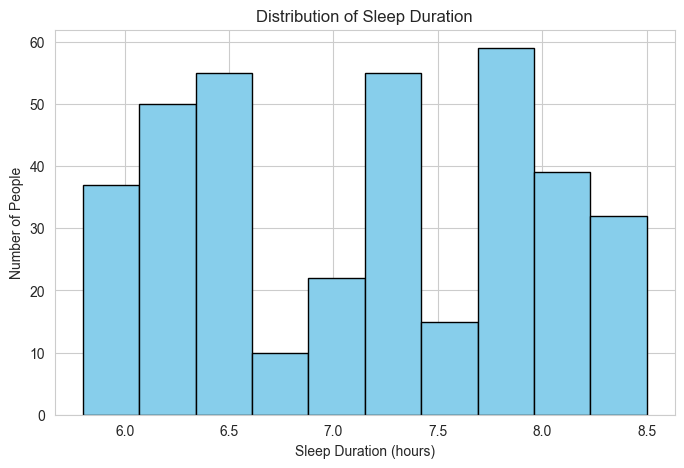

In [42]:
# Histogram for Sleep Duration

plt.hist(df["Sleep Duration"], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Number of People")
plt.show()

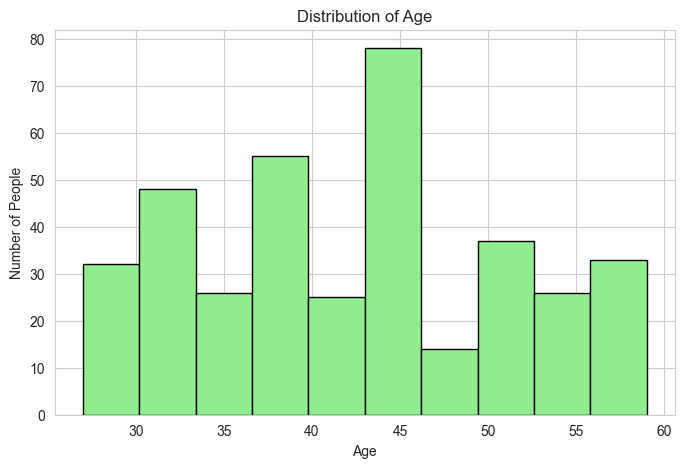

In [43]:
# Histogram for Age

plt.hist(df["Age"], bins=10, color="lightgreen", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.show()

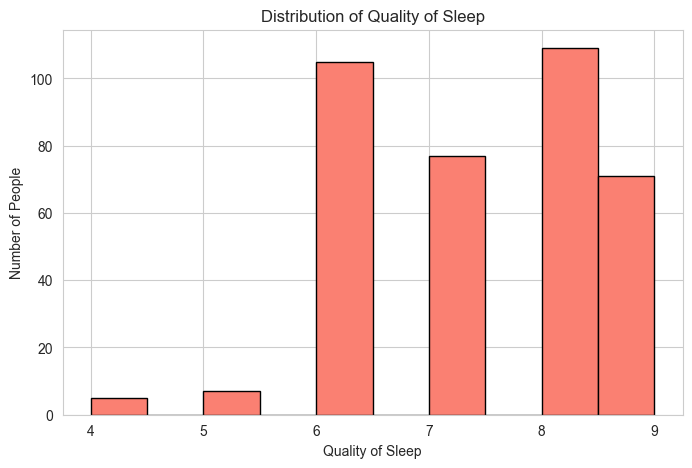

In [44]:
# Histogram for Quality of Sleep

plt.hist(df["Quality of Sleep"], bins=10, color="salmon", edgecolor="black")
plt.title("Distribution of Quality of Sleep")
plt.xlabel("Quality of Sleep")
plt.ylabel("Number of People")
plt.show()

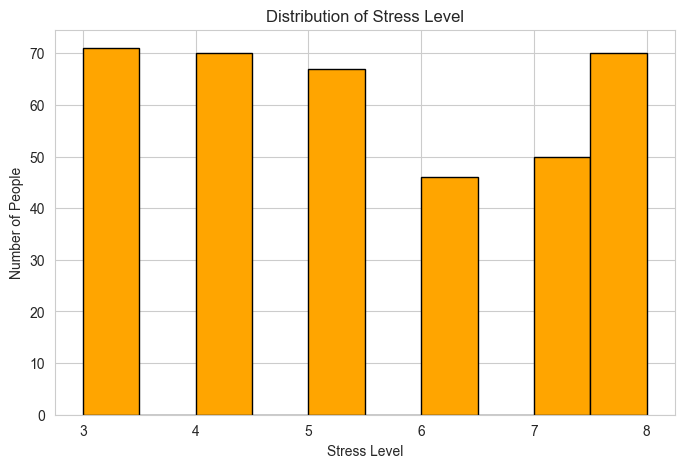

In [45]:
# Histogram for Stress Level

plt.hist(df["Stress Level"], bins=10, color="orange", edgecolor="black")
plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Number of People")
plt.show()

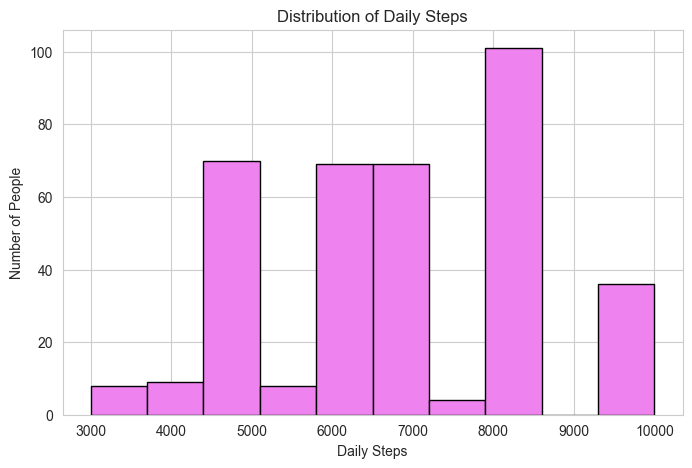

In [46]:
# Histogram for Daily Steps

plt.hist(df["Daily Steps"], bins=10, color="violet", edgecolor="black")
plt.title("Distribution of Daily Steps")
plt.xlabel("Daily Steps")
plt.ylabel("Number of People")
plt.show()

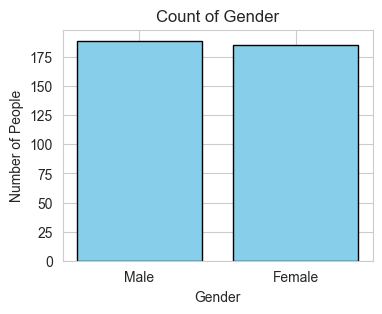

In [47]:
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(4,3))
plt.bar(gender_counts.index, gender_counts.values, color="skyblue", edgecolor="black")
plt.title("Count of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of People")
plt.show()

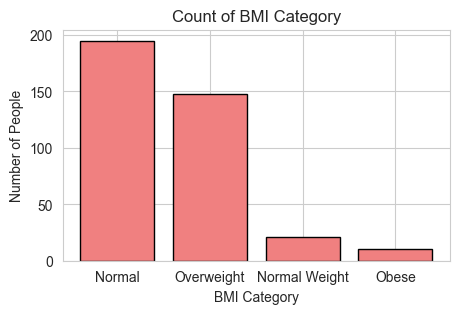

In [48]:
bmi_counts = df["BMI Category"].value_counts()
plt.figure(figsize=(5,3))
plt.bar(bmi_counts.index, bmi_counts.values, color="lightcoral", edgecolor="black")
plt.title("Count of BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Number of People")
plt.show()

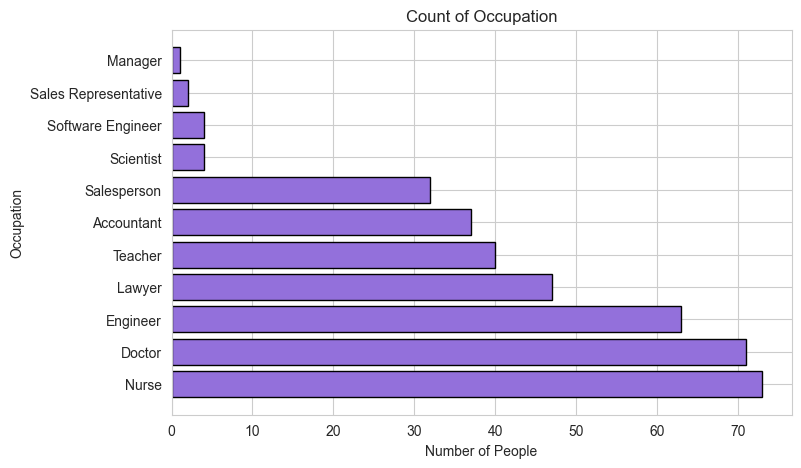

In [49]:
occupation_counts = df["Occupation"].value_counts()

plt.barh(occupation_counts.index, occupation_counts.values, color="mediumpurple", edgecolor="black")
plt.title("Count of Occupation")
plt.xlabel("Number of People")
plt.ylabel("Occupation")
plt.show()

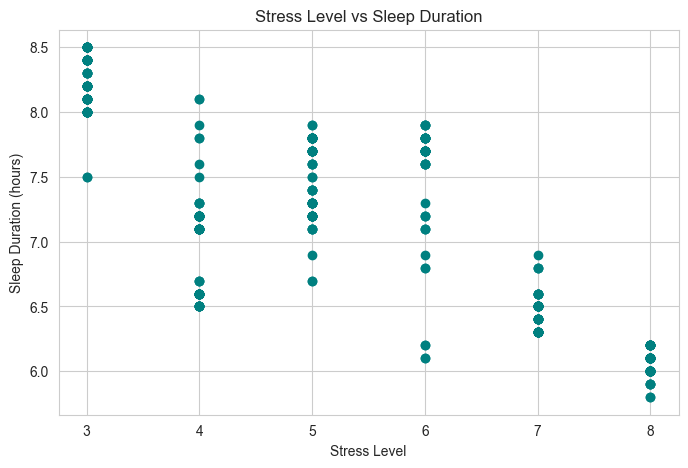

In [56]:
plt.scatter(df["Stress Level"], df["Sleep Duration"], color="teal")
plt.title("Stress Level vs Sleep Duration")
plt.xlabel("Stress Level")
plt.ylabel("Sleep Duration (hours)")
plt.show()

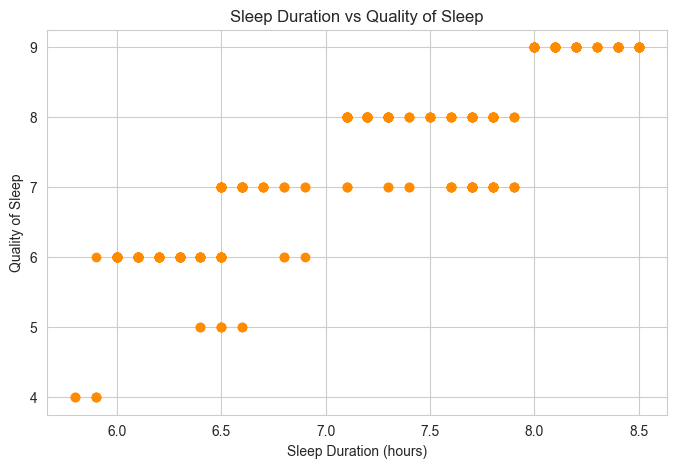

In [55]:
plt.scatter(df["Sleep Duration"], df["Quality of Sleep"], color="darkorange")
plt.title("Sleep Duration vs Quality of Sleep")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Quality of Sleep")
plt.show()

In [52]:
bmi_disorder_counts = df.groupby("BMI Category")["Sleep Disorder"].value_counts()
print(bmi_disorder_counts)

BMI Category   Sleep Disorder
Normal         None              183
               Insomnia            7
               Sleep Apnea         5
Normal Weight  None               17
               Insomnia            2
               Sleep Apnea         2
Obese          Sleep Apnea         6
               Insomnia            4
Overweight     Sleep Apnea        65
               Insomnia           64
               None               19
Name: count, dtype: int64


Overweight
Sleep Disorder
Sleep Apnea    65
Insomnia       64
None           19
Name: count, dtype: int64



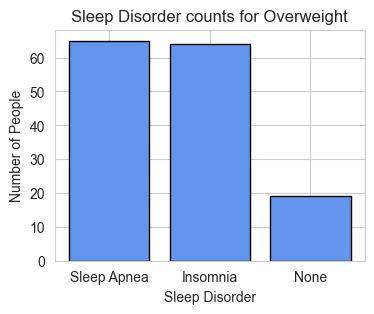

Normal
Sleep Disorder
None           183
Insomnia         7
Sleep Apnea      5
Name: count, dtype: int64



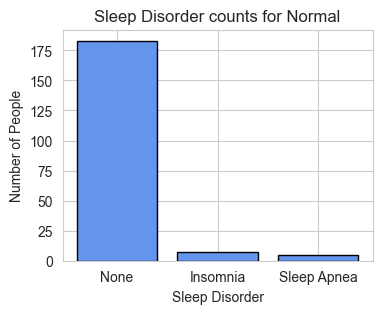

Obese
Sleep Disorder
Sleep Apnea    6
Insomnia       4
Name: count, dtype: int64



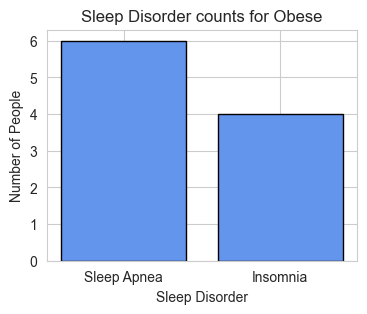

Normal Weight
Sleep Disorder
None           17
Sleep Apnea     2
Insomnia        2
Name: count, dtype: int64



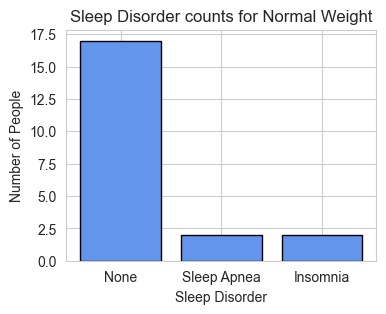

In [53]:
bmi_categories = df["BMI Category"].unique()

for bmi in bmi_categories:
    subset = df[df["BMI Category"] == bmi]
    disorder_counts = subset["Sleep Disorder"].value_counts()
    print(bmi)
    print(disorder_counts)
    print()

    plt.figure(figsize=(4,3))
    plt.bar(disorder_counts.index, disorder_counts.values, color="cornflowerblue", edgecolor="black")
    plt.title("Sleep Disorder counts for " + bmi)
    plt.xlabel("Sleep Disorder")
    plt.ylabel("Number of People")
    plt.show()

In [54]:
occupations = df["Occupation"].unique()

for occ in occupations:
    subset = df[df["Occupation"] == occ]
    disorder_counts = subset["Sleep Disorder"].value_counts()
    print(occ)
    print(disorder_counts)
    print()

Software Engineer
Sleep Disorder
None        3
Insomnia    1
Name: count, dtype: int64

Doctor
Sleep Disorder
None           64
Sleep Apnea     4
Insomnia        3
Name: count, dtype: int64

Sales Representative
Sleep Disorder
Sleep Apnea    2
Name: count, dtype: int64

Teacher
Sleep Disorder
Insomnia       27
None            9
Sleep Apnea     4
Name: count, dtype: int64

Nurse
Sleep Disorder
Sleep Apnea    61
None            9
Insomnia        3
Name: count, dtype: int64

Engineer
Sleep Disorder
None           57
Insomnia        5
Sleep Apnea     1
Name: count, dtype: int64

Accountant
Sleep Disorder
None        30
Insomnia     7
Name: count, dtype: int64

Scientist
Sleep Disorder
None           2
Sleep Apnea    2
Name: count, dtype: int64

Lawyer
Sleep Disorder
None           42
Sleep Apnea     3
Insomnia        2
Name: count, dtype: int64

Salesperson
Sleep Disorder
Insomnia       29
None            2
Sleep Apnea     1
Name: count, dtype: int64

Manager
Sleep Disorder
None    1
Name:

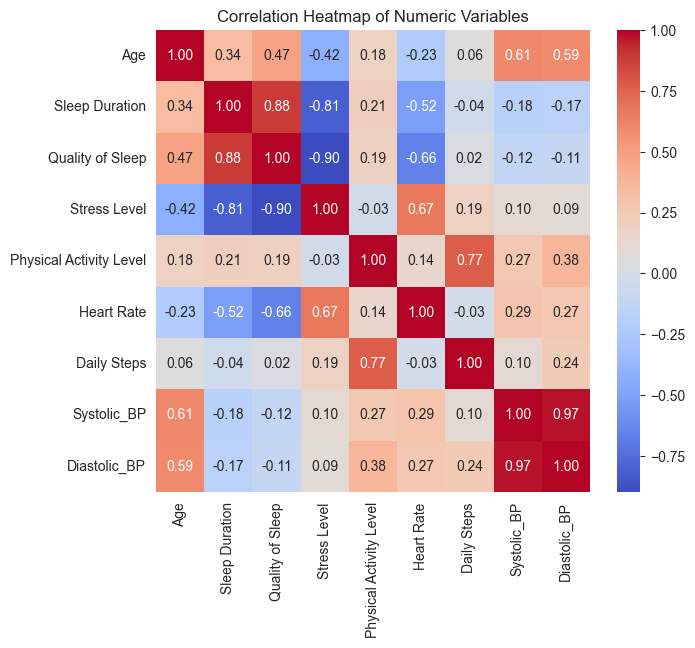

In [63]:
# selecting only numeric columns for correlation
numeric_columns = ["Age", "Sleep Duration", "Quality of Sleep", "Stress Level",
                   "Physical Activity Level", "Heart Rate", "Daily Steps",
                   "Systolic_BP", "Diastolic_BP"]

# calculating how strongly each pair of columns is related
# values close to 1 = strong positive relation, close to -1 = strong negative relation
correlation_matrix = df[numeric_columns].corr()

# plotting the heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

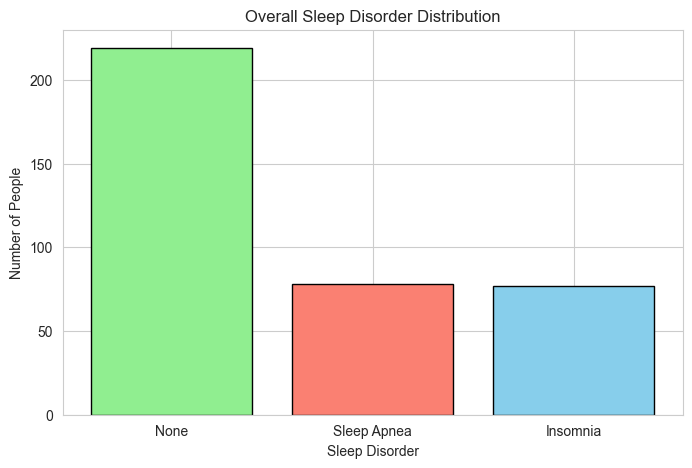

In [59]:
# counting how many people fall into each sleep disorder category
disorder_counts = df["Sleep Disorder"].value_counts()

# plotting as a bar chart
plt.bar(disorder_counts.index, disorder_counts.values, color=["lightgreen", "salmon", "skyblue"], edgecolor="black")
plt.title("Overall Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Number of People")
plt.show()

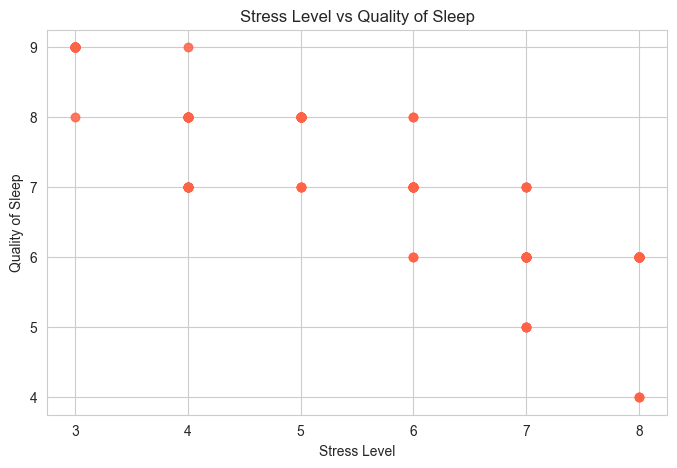

In [60]:
# scatter plot to see if higher stress means lower sleep quality
plt.scatter(df["Stress Level"], df["Quality of Sleep"], color="tomato", alpha=0.6)
plt.title("Stress Level vs Quality of Sleep")
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.show()

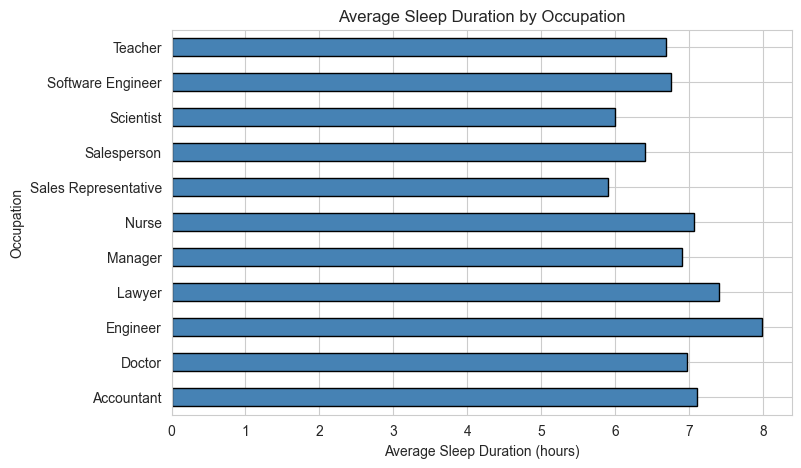

In [61]:
# grouping by occupation and calculating average sleep duration for each
avg_sleep = df.groupby("Occupation")["Sleep Duration"].mean()

# horizontal bar chart since occupation names are long
avg_sleep.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Average Sleep Duration by Occupation")
plt.xlabel("Average Sleep Duration (hours)")
plt.ylabel("Occupation")
plt.show()

In [ ]:
# Here are your complete insights, graph-wise:

# 1. Histogram — Age Distribution

# Most people in the dataset are aged between 43-45 years
# Age is not evenly spread — it clusters at specific ranges


# 2. Histogram — Stress Level Distribution

# Stress level is bimodal — people report either low stress (3-5) or very high stress (8)
# Very few people report moderate stress (6-7)


# 3. Histogram — Sleep Duration, Quality of Sleep, Daily Steps

# Sleep duration mostly falls between 6-8 hours
# Quality of Sleep ratings cluster around 6-8 out of 10
# Daily steps vary widely across people


# 4. Bar Chart — Gender

# Dataset is roughly balanced between Male and Female


# 5. Bar Chart — BMI Category

# "Normal" BMI is the most common category
# Very few people fall in the Obese category


# 6. Horizontal Bar Chart — Occupation

# Nurse is the most common occupation
# followed by Doctor, Engineer, Lawyer etc.


# 7. Scatter Plot — Stress Level vs Sleep Duration

# Clear negative relationship — higher stress means fewer hours of sleep
# People with stress level 8 sleep the least


# 8. Scatter Plot — Sleep Duration vs Quality of Sleep

# Clear positive relationship — more sleep hours means better sleep quality
# Forms a staircase pattern because Quality is rated in whole numbers


# 9. Scatter Plot — Stress Level vs Quality of Sleep

# Higher stress is linked to lower sleep quality
# Confirms stress is a key factor affecting sleep


# 10. Bar Charts — BMI Category vs Sleep Disorder

# Normal BMI → almost no sleep disorder (94% have none)
# Overweight → majority have Insomnia or Sleep Apnea
# Obese → 100% have either Insomnia or Sleep Apnea
# Strongest finding in the entire project


# 11. Correlation Heatmap

# Sleep Duration and Quality of Sleep → strongest positive correlation
# Stress Level and Sleep Duration → strongest negative correlation
# Stress Level and Quality of Sleep → strong negative correlation
# Heart Rate and Stress Level → moderate positive correlation


# 12. Bar Chart — Sleep Disorder Distribution

# "None" is the most common (majority have no disorder)
# Insomnia and Sleep Apnea are roughly equal in count


# 13. Horizontal Bar Chart — Average Sleep Duration by Occupation

# Some occupations average notably less sleep (likely high-stress jobs)
# Compare which occupation gets most vs least average sleep from your chart


# Overall Conclusion for PPT:

# Higher stress and higher BMI are the two biggest factors linked to poor sleep — less duration, lower quality, and higher chance of Insomnia or Sleep Apnea.